# Advanced Physics - Advection, Diffusion & Sources

Real astrophysical environments are rarely just diffusion. In this tutorial, we will see how to combine multiple operators and add a continuous source of particles.

## 1. Setup

We will start with an empty (vacuum) state and see how it fills up from a source.

In [1]:
import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np

from saetass import units as su
from saetass.grid import Grid
from saetass.solver import Solver
from saetass.state import State
from saetass.utils.energy_losses import Particle

# Spatial grid: 0 to 20 pc, evolved during 2 Myr
grid = Grid.uniform(
    r_min=0.0 * u.pc,
    r_max=20.0 * u.pc,
    num_r_cells=200,
    t_min=0.0 * u.Myr,
    t_max=2.0 * u.Myr,
    num_timesteps=200,
)

# Empty initial state
state = State(grid, psi_p=np.zeros(grid.shape) * su.PSI_P, particle=Particle.PROTON)

## 2. Defining a Complex Problem

We will now solve for:
1. **Advection**: Particles moving outwards due to a stellar wind.
2. **Diffusion**: Particles spreading out.
3. **Source**: A continuous injection of particles at the center ($r=0$).

Notice the `problem_type` string: the order of operators defines the operator splitting sequence.

Each physical parameter can be given in the units that are most natural for it, e.g. the wind velocity in km/s. The source is time-dependent in general, so it is given as a callable that receives the physical cell-center coordinates `r` and `p` and the time `t` as Quantities, and returns a Quantity. Since this grid has no momentum axis, `p` is `None`.

In [2]:
# Combined problem type
problem_type = "advection-diffusion-source"

# Configuration for each operator
v_centers = np.full(grid.num_cells_r, 5.0) * u.km / u.s
D_values = np.full(grid.num_cells_r, 0.5) * u.pc**2 / u.Myr


# Define a source function: continuous injection at r=0
def continuous_source(r, p, t):
    q0 = 100.0 * su.SOURCE_PSI_P
    sigma = 0.5 * u.pc
    return q0 * np.exp(-(r**2) / (2 * sigma**2))


operator_params = {
    "advection": {
        "v_centers": v_centers,
        "limiter": "vanleer",  # Numerical limiter for stability
        "order": 2,  # Second-order accurate scheme
        "cfl": 0.5,  # CFL safety factor
        "inflow_value_U": 0.0 * su.AREA * su.PSI_P,  # No inward flow from boundary
    },
    "diffusion": {"D_values": D_values},
    "source": {"source": continuous_source},
}

# Instantiate the solver
solver = Solver(
    grid=grid, state=state, problem_type=problem_type, operator_params=operator_params
)

╭─ SAETASS: Solver for Astroparticle Equation of Transport Analysis in Spherical Symmetry ─╮              
              │                                                                                          │              
              │                                     :::::::::::::::                                      │              
              │                                 :::::::::::::::::::::::                                  │              
              │                               :::::::::++++++++++::::::::                                │              
              │                              ::::::::++++++++++++++::::::::                              │              
              │                             :::::::++++++++++++++++++:::::::                             │              
              │                            ::::::::++++++++++++++++++::::::::                            │              
              │                            :::::::++++++++++++++++++++:::::::                            │              
              │                            :::::::+++++++++++++++++++::::::::                            │              
              │                            ::::::::++++++++++++++++++::::::::                            │              
              │                             ::::::::::++++++++++++++                                     │              
              │                              :::::::::::::::++++++                                       │              
              │                                :::::::::::::::::::::                                     │              
              │                                   ::::::::::::::::::::::                                 │              
              │                                       ++:::::::::::::::::::                              │              
              │                                     ++++++++++++::::::::::::                             │              
              │                                   ++++++++++++++++++:::::::::                            │              
              │                           ::::::::++++++++++++++++++++::::::::                           │              
              │                           :::::::++++++++++++++++++++++:::::::                           │              
              │                           :::::::++++++++++++++++++++++:::::::                           │              
              │                            :::::::++++++++++++++++++++:::::[

## 3. Running the Simulation

Let's run the simulation and see how the distribution evolves towards a steady state.

Output()

Output()

Output()

Output()

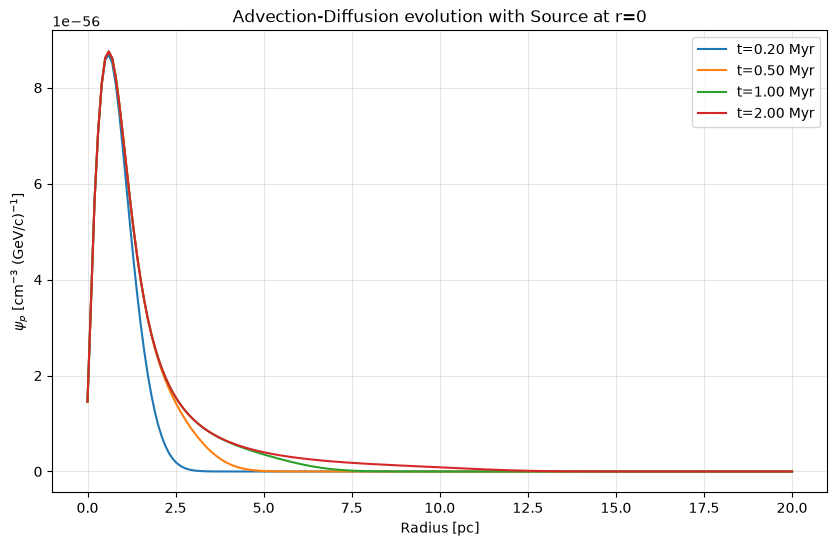

In [3]:
psi_unit = u.cm**-3 / su.MOMENTUM
plt.figure(figsize=(10, 6))

# Advance by chunks and plot
times_to_plot = [20, 50, 100, 200]
current_step = 0

for next_step in times_to_plot:
    solver.step(next_step - current_step)
    current_step = next_step
    plt.plot(
        grid.r_centers.to_value(u.pc),
        state.psi_p.to_value(psi_unit),
        label=f"t={state.t:.2f}",
    )

plt.xlabel("Radius [pc]")
plt.ylabel(r"$\psi_p$ [cm$^{-3}$ (GeV/c)$^{-1}$]")
plt.title("Advection-Diffusion evolution with Source at r=0")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 4. Understanding the Results

What are we seeing here?
- The **Source** is continuously pumping particles at the center. 
- **Diffusion** pushes them outwards from the high-density center.
- **Advection** (the wind) also carries them outwards at a speed $v_0$.

Over time, the profile starts to reach a **steady state** where the injection from the source is balanced by the transport out of the domain boundary.

## Summary

In this tutorial series, you have gone from zero to running a complete astrophysical transport simulation! 
1. You learned the SAETASS **unit system**.
2. You mastered **Grids** and **States**.
3. You learned how to use the **Solver**.
4. You combined multiple **operators** and **sources**.

In the next tutorials, we will compute the **energy losses** and the **non-thermal emissions** of cosmic rays. You are also ready to explore more advanced cases in the **Examples** section!